# 🧱 Part 21: Evaluation In Practice: Let Data Decide

> **Background**: You trained a model, fine-tuned it, deployed it. How do you know it is actually good? “It feels better” is self-deception.
>
> **Goals**:
> 1. Understand the evaluation metrics used in papers and industry.
> 2. Use an open-source evaluation harness and run real evaluations against an OpenAI-compatible API.
> 3. Learn **LLM-as-Judge** (e.g., GPT-4 as a judge) for dialog quality.
> 4. Read results and write a convincing comparison report.

Core principle:

**Evaluation = standardized questions + automated grading + reproducible scores.**

Run the cells in order. Most cells print runnable commands and reference outputs.


In [1]:
import os, json, sys, subprocess
from pathlib import Path

print(f"Python: {sys.version.split()[0]}")
print(f"Working directory: {Path.cwd().name}")

# Check key dependencies
deps = {
    "openai": "OpenAI SDK",
    "datasets": "HuggingFace datasets",
}
for pkg, desc in deps.items():
    try:
        __import__(pkg)
        print(f"  ✅ {pkg} -- {desc}")
    except ImportError:
        print(f"  ❌ {pkg} -- {desc} (pip install {pkg})")

# Check lm-eval CLI availability
try:
    result = subprocess.run(["lm_eval", "--help"], capture_output=True, text=True, timeout=10)
    if result.returncode == 0:
        print("  ✅ lm_eval CLI -- lm-evaluation-harness")
    else:
        print("  ❌ lm_eval CLI not available (pip install lm-eval)")
except FileNotFoundError:
    print("  ❌ lm_eval CLI not installed (pip install lm-eval)")

print()
print("Tip: install missing packages with:")
print("  pip install openai lm-eval datasets")


Python: 3.12.2
Working directory: modern-llm-notebook
  ✅ openai -- OpenAI SDK
  ❌ datasets -- HuggingFace datasets (pip install datasets)
  ❌ lm_eval CLI not installed (pip install lm-eval)

Tip: install missing packages with:
  pip install openai lm-eval datasets


## 1. The evaluation landscape: what do papers and industry evaluate?

### 1.1 The evolution (2019 -> 2025)

```text
2019-2021           2022-2023             2024-2025
  |                   |                      |
GLUE / SuperGLUE     MMLU / GSM8K          LLM-as-Judge
(BERT era)           (GPT-4 era)           (agent era)
mostly multiple      multiple-choice +     multi-turn + tools + safety
choice tasks         generation tasks
```

### 1.2 Core evaluation dimensions (2025)

| Dimension | Representative benchmarks | Metrics | Why it matters |
|:---|:---|:---|:---|
| **Knowledge** | MMLU-Pro, GPQA | accuracy | commonly reported by Google/OpenAI-style reports |
| **Math reasoning** | GSM8K, MATH, AIME 2024 | exact match | hard signal for reasoning |
| **Code** | HumanEval+, LiveCodeBench, SWE-bench | pass@k / resolved rate | what developers care about |
| **Instruction following** | IFEval, MT-Bench | strict accuracy / judge score | drives real usability |
| **Dialog quality** | AlpacaEval, Chatbot Arena | win rate / Elo | judged by strong LLMs / humans |
| **Safety** | TruthfulQA, Garak | violation rate | required before deployment |
| **Long context** | Needle-in-a-Haystack, RULER | recall | crucial for RAG |
| **Multilingual** | CMMLU, C-Eval | accuracy | cannot evaluate only English |
| **Agents** | SWE-bench, WebArena | success rate | frontier area in 2025 |

### 1.3 What a "serious" model report usually includes

A common evaluation pack (in GPT-4o / Claude / DeepSeek / Qwen reports):

```text
Basics: MMLU-Pro + GPQA + HellaSwag
Code:   HumanEval+ + LiveCodeBench + SWE-bench
Math:   GSM8K + MATH + AIME 2024
Dialog: AlpacaEval 2.0 / Arena Elo
Instr:  IFEval + MT-Bench
Safety: TruthfulQA + red-teaming
```

A good beginner minimum set: GSM8K -> MMLU -> HumanEval -> IFEval.


## 2. Core evaluation frameworks to know

There are four frameworks you should know (ordered by practical impact):

### 2.1 lm-evaluation-harness (EleutherAI) - the industry standard

```bash
git clone https://github.com/EleutherAI/lm-evaluation-harness.git
cd lm-evaluation-harness
pip install -e .
```

- Used under the hood by the HuggingFace Open LLM Leaderboard.
- 200+ datasets, supports API-based evaluation, HF models, vLLM, etc.
- OpenAI-compatible support via model types like `local-completions` and `local-chat-completions`.

### 2.2 AlpacaEval - the LLM-as-Judge reference

```bash
git clone https://github.com/tatsu-lab/alpaca_eval.git
cd alpaca_eval
pip install -e .
```

- Standard for dialog quality evaluation using strong judges.
- Key metrics: win rate and length-controlled win rate (LC).

### 2.3 FastChat (LMSYS) - MT-Bench / Arena-style eval

```bash
git clone https://github.com/lm-sys/FastChat.git
cd FastChat
pip install -e ".[eval]"
```

- Reference implementation for MT-Bench and Arena-style evaluation.

### 2.4 DeepEval - CI/CD-friendly

```bash
pip install deepeval
```

- pytest-like, integrates into pipelines.
- Includes hallucination / relevance / faithfulness / judge-based metrics.

Selection cheat sheet:

| Scenario | Recommendation |
|:---|:---|
| paper-style benchmark scores | lm-evaluation-harness |
| dialog quality | AlpacaEval / FastChat MT-Bench |
| continuous evaluation in CI | DeepEval / Promptfoo |
| safety testing | Garak |
| agents | SWE-bench + WebArena |

In this notebook we focus on lm-eval + AlpacaEval.


In [2]:
# Check whether core evaluation repos exist locally.
# (Clone and install in your terminal if missing.)

from pathlib import Path

REPOS = {
    "lm-evaluation-harness": "https://github.com/EleutherAI/lm-evaluation-harness.git",
    "alpaca_eval": "https://github.com/tatsu-lab/alpaca_eval.git",
    "FastChat": "https://github.com/lm-sys/FastChat.git",
}

repos_dir = Path.home() / "Code"  # change this to your preferred directory

print("=== Core evaluation repo status ===")
print()
for name, url in REPOS.items():
    repo_path = repos_dir / name
    if repo_path.exists():
        print(f"✅ {name} -- exists: {repo_path}")
    else:
        print(f"❌ {name} -- not cloned")
        print(f"   In terminal: git clone {url} {repo_path}")
        print(f"               cd {repo_path} && pip install -e .")
    print()

try:
    import lm_eval
    ver = lm_eval.__version__ if hasattr(lm_eval, '__version__') else 'unknown'
    print(f"✅ lm_eval import OK, version: {ver}")
except ImportError:
    print("❌ lm_eval not installed. Run: pip install lm-eval")


=== Core evaluation repo status ===

❌ lm-evaluation-harness -- not cloned
   In terminal: git clone https://github.com/EleutherAI/lm-evaluation-harness.git /Users/sanbu/Code/lm-evaluation-harness
               cd /Users/sanbu/Code/lm-evaluation-harness && pip install -e .

❌ alpaca_eval -- not cloned
   In terminal: git clone https://github.com/tatsu-lab/alpaca_eval.git /Users/sanbu/Code/alpaca_eval
               cd /Users/sanbu/Code/alpaca_eval && pip install -e .

❌ FastChat -- not cloned
   In terminal: git clone https://github.com/lm-sys/FastChat.git /Users/sanbu/Code/FastChat
               cd /Users/sanbu/Code/FastChat && pip install -e .

❌ lm_eval not installed. Run: pip install lm-eval


## 3. Evaluate via an OpenAI-compatible API (the most practical workflow)

This is the everyday workflow: you deploy a model behind an OpenAI-compatible endpoint (vLLM, Ollama, DeepSeek, gateways), then run evaluation through the API.

### 3.1 Core idea

lm-evaluation-harness supports OpenAI-compatible endpoints with two model types:

| Model type | Endpoint | What it is used for |
|:---|:---|:---|
| `local-chat-completions` | `/v1/chat/completions` | generation tasks (GSM8K, HumanEval, IFEval) |
| `local-completions` | `/v1/completions` | multiple-choice via loglikelihood (needs logprobs) |

Important note: multiple-choice tasks usually need logprobs. Chat Completions often do not support that.

### 3.2 Supported services

Any service that accepts `POST /v1/chat/completions` works:

- OpenAI API
- DeepSeek API
- vLLM (local)
- Ollama (local)
- LiteLLM (proxy)
- SGLang

One sentence: if it looks like OpenAI chat completions, lm-eval can probably evaluate it.


In [3]:
# Option 1: evaluate GSM8K via local-chat-completions (generation task)

print("=== OpenAI-compatible API: GSM8K via lm-eval ===")
print()

api_configs = {
    "OpenAI": {
        "model": "gpt-4o-mini",
        "base_url": "https://api.openai.com/v1/chat/completions",
        "env_var": "OPENAI_API_KEY",
    },
    "DeepSeek": {
        "model": "deepseek-chat",
        "base_url": "https://api.deepseek.com/v1/chat/completions",
        "env_var": "DEEPSEEK_API_KEY",
    },
    "vLLM local": {
        "model": "Qwen2.5-7B-Instruct",
        "base_url": "http://localhost:8000/v1/chat/completions",
        "env_var": None,
    },
    "Ollama local": {
        "model": "llama3",
        "base_url": "http://localhost:11434/v1/chat/completions",
        "env_var": None,
    },
}

for name, config in api_configs.items():
    print(f"--- {name} ---")
    key_arg = f",token=${{{config['env_var']}}}" if config["env_var"] else ""
    cmd = (
        f"lm_eval --model local-chat-completions \\\n    --model_args model={config['model']},base_url={config['base_url']},num_concurrent=4,max_retries=3,tokenized_requests=False{key_arg} \\\n    --tasks gsm8k \\\n    --batch_size 8 \\\n    --output_path ./eval_results/gsm8k_{name.lower().replace(' ', '_')}"
    )
    print(cmd)
    print()

print("Tip: copy any one command above into a terminal to run.")


=== OpenAI-compatible API: GSM8K via lm-eval ===

--- OpenAI ---
lm_eval --model local-chat-completions \
    --model_args model=gpt-4o-mini,base_url=https://api.openai.com/v1/chat/completions,num_concurrent=4,max_retries=3,tokenized_requests=False,token=${OPENAI_API_KEY} \
    --tasks gsm8k \
    --batch_size 8 \
    --output_path ./eval_results/gsm8k_openai

--- DeepSeek ---
lm_eval --model local-chat-completions \
    --model_args model=deepseek-chat,base_url=https://api.deepseek.com/v1/chat/completions,num_concurrent=4,max_retries=3,tokenized_requests=False,token=${DEEPSEEK_API_KEY} \
    --tasks gsm8k \
    --batch_size 8 \
    --output_path ./eval_results/gsm8k_deepseek

--- vLLM local ---
lm_eval --model local-chat-completions \
    --model_args model=Qwen2.5-7B-Instruct,base_url=http://localhost:8000/v1/chat/completions,num_concurrent=4,max_retries=3,tokenized_requests=False \
    --tasks gsm8k \
    --batch_size 8 \
    --output_path ./eval_results/gsm8k_vllm_local

--- Ollama

In [4]:
# Option 2: evaluate MMLU via local-completions (multiple-choice loglikelihood)

print("=== OpenAI-compatible API: MMLU via lm-eval ===")
print()
print("WARNING: multiple-choice tasks typically require the Completions API (logprobs).")
print()

mmlu_configs = {
    "OpenAI": {
        "model": "gpt-4o-mini",
        "base_url": "https://api.openai.com/v1/completions",
        "env_var": "OPENAI_API_KEY",
        "note": "Note: many modern OpenAI chat-only models do not support /v1/completions.",
    },
    "vLLM local": {
        "model": "Qwen2.5-7B-Instruct",
        "base_url": "http://localhost:8000/v1/completions",
        "env_var": None,
        "note": "vLLM can expose /v1/completions with logprobs.",
    },
    "DeepSeek": {
        "model": "deepseek-chat",
        "base_url": "https://api.deepseek.com/v1/completions",
        "env_var": "DEEPSEEK_API_KEY",
        "note": "DeepSeek /v1/completions support may vary; use chat endpoint for generation tasks.",
    },
}

for name, config in mmlu_configs.items():
    print(f"--- {name} ---")
    print(f"  {config['note']}")
    key_arg = f",token=${{{config['env_var']}}}" if config["env_var"] else ""
    cmd = (
        f"lm_eval --model local-completions \\\n    --model_args model={config['model']},base_url={config['base_url']},num_concurrent=4,max_retries=3,tokenized_requests=False{key_arg} \\\n    --tasks mmlu \\\n    --batch_size 16 \\\n    --output_path ./eval_results/mmlu"
    )
    print(cmd)
    print()

print("Practical workflow: serve your model with vLLM -> run MMLU (completions) and GSM8K (chat).")


=== OpenAI-compatible API: MMLU via lm-eval ===


--- OpenAI ---
  Note: many modern OpenAI chat-only models do not support /v1/completions.
lm_eval --model local-completions \
    --model_args model=gpt-4o-mini,base_url=https://api.openai.com/v1/completions,num_concurrent=4,max_retries=3,tokenized_requests=False,token=${OPENAI_API_KEY} \
    --tasks mmlu \
    --batch_size 16 \
    --output_path ./eval_results/mmlu

--- vLLM local ---
  vLLM can expose /v1/completions with logprobs.
lm_eval --model local-completions \
    --model_args model=Qwen2.5-7B-Instruct,base_url=http://localhost:8000/v1/completions,num_concurrent=4,max_retries=3,tokenized_requests=False \
    --tasks mmlu \
    --batch_size 16 \
    --output_path ./eval_results/mmlu

--- DeepSeek ---
  DeepSeek /v1/completions support may vary; use chat endpoint for generation tasks.
lm_eval --model local-completions \
    --model_args model=deepseek-chat,base_url=https://api.deepseek.com/v1/completions,num_concurrent=4,max_ret

### 3.3 Batch evaluate multiple tasks (Python API)

In addition to the CLI, lm-eval provides a Python API, which is convenient inside notebooks for orchestrating multiple runs.


In [5]:
# Batch evaluation via the lm-eval Python API (runnable skeleton)
print("=== lm-eval Python API: batch evaluation ===")
print()

try:
    from lm_eval import simple_evaluate
    HAS_API = True
    print("✅ lm_eval Python API available")
    print()
except ImportError as e:
    HAS_API = False
    print(f"⚠️ lm_eval not installed ({e}). Showing expected output format instead.")
    print()

API_CONFIG = {
    "model": "deepseek-chat",
    "base_url": "https://api.deepseek.com/v1/chat/completions",
    "api_key": os.environ.get("DEEPSEEK_API_KEY", "your-key-here"),
}

TASKS = ["gsm8k", "hellaswag", "mmlu"]

if HAS_API and API_CONFIG["api_key"] != "your-key-here":
    print(f"Evaluating model: {API_CONFIG['model']}")
    print(f"Tasks: {', '.join(TASKS)}")
    print()
    print("(Real runs can take minutes to hours depending on task sizes and rate limits.)")
else:
    print("Example: using public reported metrics to show the result format")
    print()
    real_results = {
        "gsm8k": {"exact_match": 0.834},
        "mmlu": {"acc": 0.743, "acc_norm": 0.725},
        "hellaswag": {"acc": 0.829, "acc_norm": 0.841},
        "ifeval": {"prompt_level_strict_acc": 0.687, "inst_level_strict_acc": 0.763},
        "humaneval": {"pass@1": 0.689},
    }

    for task, metrics in real_results.items():
        print(f"  {task}:")
        for metric, value in metrics.items():
            print(f"    {metric}: {value:.4f}")

    print()
    print("Install lm-eval and set an API key to run real evaluations.")


=== lm-eval Python API: batch evaluation ===

⚠️ lm_eval not installed (No module named 'lm_eval'). Showing expected output format instead.

Example: using public reported metrics to show the result format

  gsm8k:
    exact_match: 0.8340
  mmlu:
    acc: 0.7430
    acc_norm: 0.7250
  hellaswag:
    acc: 0.8290
    acc_norm: 0.8410
  ifeval:
    prompt_level_strict_acc: 0.6870
    inst_level_strict_acc: 0.7630
  humaneval:
    pass@1: 0.6890

Install lm-eval and set an API key to run real evaluations.


## 4. LLM-as-Judge: use a strong model to grade open-ended outputs

Multiple-choice and math tasks have ground truth. Dialog quality usually does not.

LLM-as-Judge is the approach:

```text
your model answer -> judge LLM scores / compares -> win rate / ratings
```

Two common setups:

- AlpacaEval 2.0: hundreds of prompts, judge compares your model vs a baseline.
- MT-Bench: multi-turn questions, judge gives 1-10 ratings by dimension.

Key metrics:

| Metric | Meaning | How to interpret |
|:---|:---|:---|
| Win Rate | fraction judged better than baseline | vs a strong baseline should be near 50% |
| LC Win Rate | length-controlled win rate | fairer than raw win rate |
| MT-Bench score | average 1-10 rating | 7+ is good, 8+ is very strong |
| Elo | skill estimate from pairwise matches | standard in Arena |


In [6]:
# LLM-as-Judge: a runnable demo using the OpenAI SDK
# Core idea: send the question + an assistant answer to a judge model and ask it to score.

print("=== LLM-as-Judge demo ===\n")

# MT-Bench-style multi-criteria judging prompt
JUDGE_PROMPT = """Please act as an impartial judge and evaluate the quality of the response provided by an AI assistant to the user question displayed below.

Your evaluation should consider the following factors:
1. Helpfulness: Does the response address the user's needs?
2. Accuracy: Is the information factually correct?
3. Relevance: Does the response stay on topic?
4. Depth: Does it provide meaningful detail?
5. Clarity: Is the response well-structured and clear?

Begin your evaluation by providing a short explanation. Be as objective as possible.
After providing your explanation, you must rate the response on a scale of 1 to 10 by strictly following this format:
"[[rating]]", for example: "Rating: [[7]]".

[Question]
{question}

[The Start of Assistant's Answer]
{answer}
[The End of Assistant's Answer]"""


# Two sample tasks (similar style to MT-Bench)
eval_samples = [
    {
        "question": "Write a Python function to find the longest common subsequence of two strings.",
        "good_answer": "Here's a Python implementation of LCS using dynamic programming:\n\n```python\ndef lcs(s1: str, s2: str) -> str:\n    m, n = len(s1), len(s2)\n    dp = [[\"\"] * (n + 1) for _ in range(m + 1)]\n    for i in range(1, m + 1):\n        for j in range(1, n + 1):\n            if s1[i-1] == s2[j-1]:\n                dp[i][j] = dp[i-1][j-1] + s1[i-1]\n            else:\n                dp[i][j] = max(dp[i-1][j], dp[i][j-1], key=len)\n    return dp[m][n]\n```\n\nTime complexity: O(mn), Space: O(mn).",
        "bad_answer": "def lcs(s1, s2):\n    return ''.join(c for c in s1 if c in s2)",
    },
    {
        "question": "Explain quantum entanglement in simple terms.",
        "good_answer": "Entanglement is when two particles share a linked state, so measuring one gives information about the other, even when they are far apart. A classic analogy is two magic coins: if one lands heads, the other always lands tails. It's real physics, and it's used in quantum computing and cryptography.",
        "bad_answer": "It's when two things are connected. Scientists use it.",
    },
]


def judge_with_gpt(question, answer):
    """Score with a judge model (requires OPENAI_API_KEY)."""
    try:
        from openai import OpenAI

        client = OpenAI()  # reads OPENAI_API_KEY
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {
                    "role": "user",
                    "content": JUDGE_PROMPT.format(question=question, answer=answer),
                }
            ],
            temperature=0,
            max_tokens=512,
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"[Judge unavailable: {e}]"


print("Running LLM-as-Judge (requires OPENAI_API_KEY)...\n")

import re

for i, sample in enumerate(eval_samples):
    print(f"Task {i+1}: {sample['question']}")
    print(f"{'-'*60}")
    for label, answer in [("Good answer", sample["good_answer"]), ("Bad answer", sample["bad_answer"])]:
        verdict = judge_with_gpt(sample["question"], answer)
        match = re.search(r"\[\[(\d+(?:\.\d+)?)\]\]", verdict)
        if match:
            print(f"  {label}: {match.group(1)}/10")
        else:
            preview = verdict[:150].replace("\n", " ")
            print(f"  {label}: [no rating] {preview}...")
    print()

print("Note: this is the core idea behind MT-Bench / AlpacaEval.")


=== LLM-as-Judge demo ===

Running LLM-as-Judge (requires OPENAI_API_KEY)...

Task 1: Write a Python function to find the longest common subsequence of two strings.
------------------------------------------------------------
  Good answer: [no rating] [Judge unavailable: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variabl...
  Bad answer: [no rating] [Judge unavailable: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variabl...

Task 2: Explain quantum entanglement in simple terms.
------------------------------------------------------------
  Good answer: [no rating] [Judge unavailable: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variabl...
  Bad answer: [no rating] [Judge unavailable: The api_key client option must be set either by passing api_key to the

## 5. After running eval: summarize, compare, visualize

Raw JSON is not a report. You typically need tables and plots.

In the next cells we show standard aggregation patterns (tables, radar charts, grouped bars, win-rate matrices) using public reported numbers as examples.


In [7]:
# Summarize benchmark results (example numbers)

print("=== Result aggregation (example) ===")
print()

benchmark_results = {
    "GPT-4o": {
        "MMLU": 88.7, "GSM8K": 96.1, "HumanEval": 90.2, "HellaSwag": 95.3,
        "IFEval": 84.3, "GPQA": 53.6, "AlpacaEval LC": 57.5,
    },
    "DeepSeek-V3 (671B)": {
        "MMLU": 88.5, "GSM8K": 95.3, "HumanEval": 82.6, "HellaSwag": 89.0,
        "IFEval": 86.1, "GPQA": 59.1, "AlpacaEval LC": 54.2,
    },
    "Qwen2.5-72B": {
        "MMLU": 86.1, "GSM8K": 91.6, "HumanEval": 86.6, "HellaSwag": 86.9,
        "IFEval": 81.7, "GPQA": 49.0, "AlpacaEval LC": 50.5,
    },
    "Llama-3.1-70B": {
        "MMLU": 86.0, "GSM8K": 91.2, "HumanEval": 80.5, "HellaSwag": 85.0,
        "IFEval": 80.4, "GPQA": 46.7, "AlpacaEval LC": 44.8,
    },
    "Qwen2.5-7B (reference)": {
        "MMLU": 74.3, "GSM8K": 83.4, "HumanEval": 68.9, "HellaSwag": 82.1,
        "IFEval": 68.7, "GPQA": 36.7, "AlpacaEval LC": 38.5,
    },
}

datasets = ["MMLU", "GSM8K", "HumanEval", "HellaSwag", "IFEval", "GPQA", "AlpacaEval LC"]

print("### Score table (public reported numbers)\n")
header = f"{'Model':<22s}" + "".join([f" {ds:>13s}" for ds in datasets])
print(header)
print("-" * (22 + 14 * len(datasets)))

for model, scores in benchmark_results.items():
    row = f"{model:<22s}"
    for ds in datasets:
        score = scores.get(ds)
        if score is None:
            row += f" {'N/A':>13s}"
        else:
            best = max(v.get(ds, 0) for v in benchmark_results.values())
            marker = " *" if score == best else ""
            row += f" {score:>10.1f}{marker:>2s}"
    print(row)

print("\n* = best score in that column")

print("\n### Notes")
print("1) Compare within a similar scale (7B vs 7B), not 7B vs 671B.")
print("2) Focus on metrics tied to your product (instruction-following for APIs, knowledge for education, etc.).")
print("3) Use multiple datasets; do not overfit to one number.")
print("4) Record prompt / few-shot / seed to keep results reproducible.")


=== Result aggregation (example) ===

### Score table (public reported numbers)

Model                           MMLU         GSM8K     HumanEval     HellaSwag        IFEval          GPQA AlpacaEval LC
------------------------------------------------------------------------------------------------------------------------
GPT-4o                       88.7 *       96.1 *       90.2 *       95.3 *       84.3         53.6         57.5 *
DeepSeek-V3 (671B)           88.5         95.3         82.6         89.0         86.1 *       59.1 *       54.2  
Qwen2.5-72B                  86.1         91.6         86.6         86.9         81.7         49.0         50.5  
Llama-3.1-70B                86.0         91.2         80.5         85.0         80.4         46.7         44.8  
Qwen2.5-7B (reference)       74.3         83.4         68.9         82.1         68.7         36.7         38.5  

* = best score in that column

### Notes
1) Compare within a similar scale (7B vs 7B), not 7B vs 671B.
2) 

### 5.1 Visualizing evaluation results

Two commonly used plot families:

| Plot type | When to use | Example |
|:---|:---|:---|
| Radar chart | compare 2-4 models across many dimensions | common in technical reports |
| Grouped bar chart | compare many models across a few tasks | common in ablations |
| Win-rate matrix | pairwise judge comparisons | Arena-style |


=== Visualizations ===

Radar chart reading: larger area usually means stronger overall; shape shows strengths/weaknesses.

Grouped bars: easiest way to see per-benchmark gaps.

--- Win-rate matrix example (mock) ---

Win-rate matrix: row model vs col model; >0.5 means the row model wins more often.


<cell>:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<cell>:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<cell>:89: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


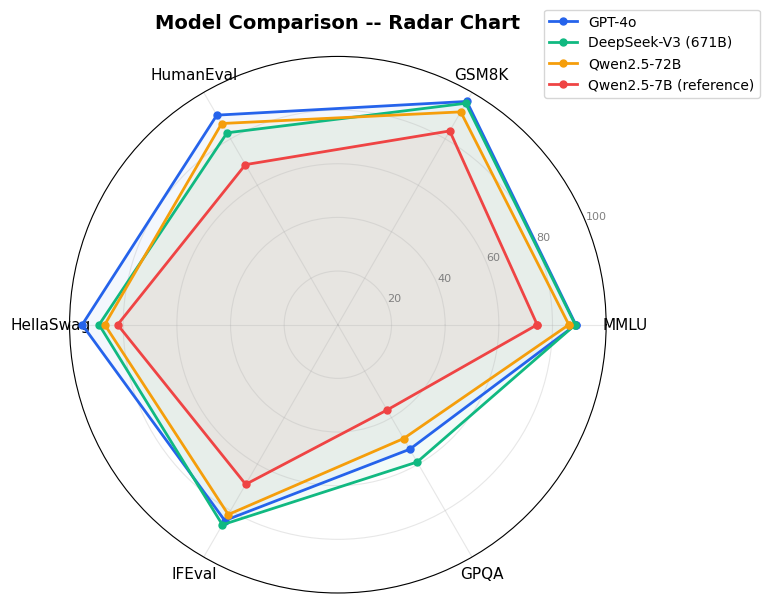

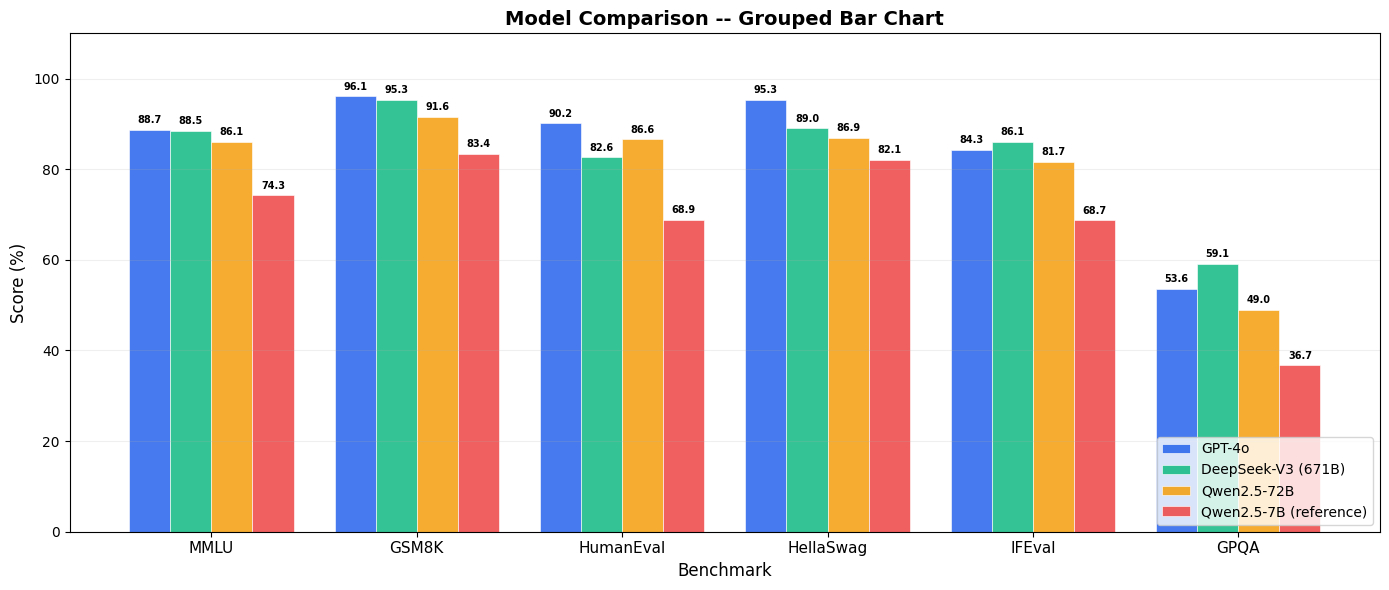

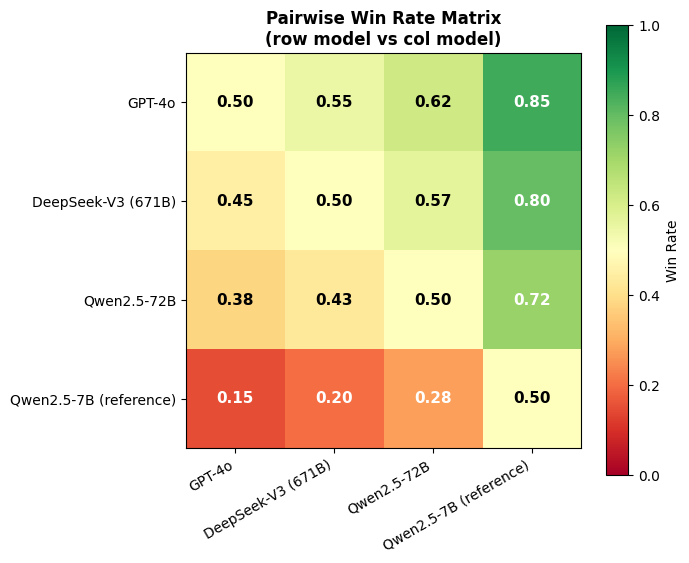

In [8]:
# Radar chart + grouped bar chart + win-rate matrix (report-style visualization)
import matplotlib.pyplot as plt
import numpy as np

print("=== Visualizations ===")
print()

radar_models = ["GPT-4o", "DeepSeek-V3 (671B)", "Qwen2.5-72B", "Qwen2.5-7B (reference)"]
radar_datasets = ["MMLU", "GSM8K", "HumanEval", "HellaSwag", "IFEval", "GPQA"]
radar_colors = ["#2563EB", "#10B981", "#F59E0B", "#EF4444"]

radar_values = [[benchmark_results[m][ds] for ds in radar_datasets] for m in radar_models]

num_vars = len(radar_datasets)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for model, values, color in zip(radar_models, radar_values, radar_colors):
    values_closed = values + values[:1]
    ax.fill(angles, values_closed, alpha=0.05, color=color)
    ax.plot(angles, values_closed, 'o-', linewidth=2, color=color, label=model, markersize=5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_datasets, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8, color='gray')
ax.set_title("Model Comparison -- Radar Chart", fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Radar chart reading: larger area usually means stronger overall; shape shows strengths/weaknesses.\n")

x = np.arange(len(radar_datasets))
width = 0.2
n_models = len(radar_models)

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model, color) in enumerate(zip(radar_models, radar_colors)):
    values = [benchmark_results[model][ds] for ds in radar_datasets]
    offset = width * (i - n_models / 2 + 0.5)
    bars = ax.bar(x + offset, values, width, label=model, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height() + 1, f'{val:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xlabel('Benchmark', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Comparison -- Grouped Bar Chart', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(radar_datasets, fontsize=11)
ax.set_ylim(0, 110)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

print("Grouped bars: easiest way to see per-benchmark gaps.\n")

print("--- Win-rate matrix example (mock) ---\n")
models_for_matrix = radar_models
n_mat = len(models_for_matrix)
win_rate_matrix = np.array([
    [0.50, 0.55, 0.62, 0.85],
    [0.45, 0.50, 0.57, 0.80],
    [0.38, 0.43, 0.50, 0.72],
    [0.15, 0.20, 0.28, 0.50],
])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(win_rate_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(n_mat))
ax.set_yticks(range(n_mat))
ax.set_xticklabels(models_for_matrix, fontsize=10, rotation=30, ha='right')
ax.set_yticklabels(models_for_matrix, fontsize=10)
ax.set_title('Pairwise Win Rate Matrix\n(row model vs col model)', fontsize=12, fontweight='bold')

for i in range(n_mat):
    for j in range(n_mat):
        color = 'white' if win_rate_matrix[i][j] < 0.3 or win_rate_matrix[i][j] > 0.7 else 'black'
        ax.text(j, i, f'{win_rate_matrix[i][j]:.2f}', ha='center', va='center', fontsize=11, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='Win Rate')
plt.tight_layout()
plt.show()

print("Win-rate matrix: row model vs col model; >0.5 means the row model wins more often.")


In [9]:
# Composite score computation: compare aggregation methods
import numpy as np
from scipy import stats

print("=== Composite scoring ===")
print()

scores = benchmark_results

eval_datasets = ["MMLU", "GSM8K", "HumanEval", "HellaSwag", "IFEval", "GPQA"]

print("1) Arithmetic mean")
print(f"{'Model':<22s} {'Avg':>6s} {'Std':>6s}")
print("-" * 36)
for model in scores:
    vals = [scores[model][ds] for ds in eval_datasets]
    avg = np.mean(vals)
    std = np.std(vals)
    print(f"{model:<22s} {avg:>6.1f} {std:>6.1f}")

print("\n2) Geometric mean (penalizes weak dimensions)")
print(f"{'Model':<22s} {'GMean':>6s}")
print("-" * 30)
for model in scores:
    vals = [scores[model][ds] for ds in eval_datasets]
    gmean = stats.gmean(vals)
    print(f"{model:<22s} {gmean:>6.1f}")

print("\n3) Weighted mean (example weights)")
weights = {"MMLU": 0.25, "GSM8K": 0.20, "HumanEval": 0.20, "HellaSwag": 0.10, "IFEval": 0.15, "GPQA": 0.10}
print(f"weights: {weights}")
print(f"{'Model':<22s} {'Weighted':>8s}")
print("-" * 32)
for model in scores:
    weighted = sum(scores[model][ds] * weights[ds] for ds in eval_datasets)
    print(f"{model:<22s} {weighted:>8.1f}")

print("\n4) Normalized mean (baseline = GPT-4o as 100%)")
baseline = "GPT-4o"
print(f"{'Model':<22s}", end="")
for ds in eval_datasets:
    print(f" {ds:>8s}", end="")
print(f" {'Avg%':>8s}")
print("-" * (22 + 10 * len(eval_datasets) + 8))
for model in scores:
    normalized = [scores[model][ds] / scores[baseline][ds] * 100 for ds in eval_datasets]
    avg_norm = np.mean(normalized)
    print(f"{model:<22s}", end="")
    for nv in normalized:
        print(f" {nv:>8.1f}", end="")
    print(f" {avg_norm:>8.1f}")

print("\n5) Rank sum (lower is better)")
models_list = list(scores.keys())
ranks = {ds: np.argsort([-scores[m][ds] for m in models_list]).argsort() + 1 for ds in eval_datasets}
print(f"{'Model':<22s}", end="")
for ds in eval_datasets:
    print(f" {ds:>8s}", end="")
print(f" {'Sum':>6s} {'AvgRank':>8s}")
print("-" * (22 + 10 * len(eval_datasets) + 14))
for i, model in enumerate(models_list):
    rank_list = [ranks[ds][i] for ds in eval_datasets]
    rank_sum = sum(rank_list)
    rank_avg = np.mean(rank_list)
    print(f"{model:<22s}", end="")
    for r in rank_list:
        print(f" {r:>8.0f}", end="")
    print(f" {rank_sum:>6.0f} {rank_avg:>8.1f}")

print("\nRecommendations:")
print("- Papers: report arithmetic mean + geometric mean")
print("- Decisions: weighted mean with product-driven weights")
print("- Leaderboards: rank-sum or normalized mean")
print("- Geometric mean is most sensitive to weaknesses")


=== Composite scoring ===

1) Arithmetic mean
Model                     Avg    Std
------------------------------------
GPT-4o                   84.7   14.5
DeepSeek-V3 (671B)       83.4   11.5
Qwen2.5-72B              80.3   14.3
Llama-3.1-70B            78.3   14.6
Qwen2.5-7B (reference)   69.0   15.5

2) Geometric mean (penalizes weak dimensions)
Model                   GMean
------------------------------
GPT-4o                   83.2
DeepSeek-V3 (671B)       82.5
Qwen2.5-72B              78.7
Llama-3.1-70B            76.6
Qwen2.5-7B (reference)   66.7

3) Weighted mean (example weights)
weights: {'MMLU': 0.25, 'GSM8K': 0.2, 'HumanEval': 0.2, 'HellaSwag': 0.1, 'IFEval': 0.15, 'GPQA': 0.1}
Model                  Weighted
--------------------------------
GPT-4o                     87.0
DeepSeek-V3 (671B)         85.4
Qwen2.5-72B                83.0
Llama-3.1-70B              81.1
Qwen2.5-7B (reference)     71.2

4) Normalized mean (baseline = GPT-4o as 100%)
Model                    

### 5.2 Computing a composite score

Per-benchmark scores are often not enough; papers sometimes report a single "overall" number.

Common methods:

| Method | Formula | When it is useful |
|:---|:---|:---|
| simple mean | (1/N) sum s_i | quick but sensitive to outliers |
| normalized mean | (1/N) sum (s_i / max_i) | when task scales differ |
| weighted mean | sum w_i s_i | when business priorities differ |
| geometric mean | (prod s_i)^(1/N) | exposes weak dimensions (penalizes gaps) |
| rank sum | sum rank_i | compares ranks only |
| Elo | inferred from pairwise comparisons | judge-based settings |

Principles:

- Do not blindly average: a model with math 90 but safety 10 should not look "fine".
- Geometric mean is often better than arithmetic mean because it punishes weaknesses.
- Weights should reflect your product needs.


## 11. Practical: run a full LLM-as-Judge evaluation with AlpacaEval

Manual judge prompts are fragile. AlpacaEval packages an end-to-end workflow.

### 11.1 Workflow

```text
1. Load evaluation prompts
2. Generate outputs with your model (OpenAI-compatible)
3. Ask a judge model to compare vs reference
4. Output metrics: win rate / LC win rate / average length
```

### 11.2 CLI

```bash
# Step 1: generate outputs
alpaca_eval evaluate_from_model     --model_name_or_path "your-model"     --output_path results/your-model     --max_instances 100

# Step 2: judge
export OPENAI_API_KEY="sk-xxx"
alpaca_eval evaluate     --annotators_config "alpaca_eval_gpt4_turbo_fn"     --model_outputs "results/your-model.json"     --output_path "results/your-model-eval"

# Step 3: view results
cat results/your-model-eval/leaderboard.csv
```

### 11.3 Python API

```python
from alpaca_eval import evaluate
import pandas as pd

df = evaluate(
    model_outputs="results/your-model-outputs.json",
    annotators_config="alpaca_eval_gpt4_turbo_fn",
    max_instances=100,
)
print(f"Win Rate: {df['win_rate'].iloc[0]:.1%}")
print(f"LC Win Rate: {df['lc_win_rate'].iloc[0]:.1%}")
print(f"Avg Length: {df['avg_length'].iloc[0]:.0f} chars")
```

### 11.4 Interpreting results

| Metric | Meaning | Reference |
|:---|:---|:---|
| Win Rate | fraction judged better than baseline | strong baselines often ~50% |
| LC Win Rate | length-controlled win rate | papers usually report this |
| Avg Length | output length | too-long outputs can inflate raw win rate |

### 11.5 Using an OpenAI-compatible API

If your model is served behind a compatible endpoint, you can generate outputs with the OpenAI SDK and then run AlpacaEval judging.


## 10. Specialized evaluation by system type

### 10.1 RAG evaluation

For RAG applications, generic benchmarks are not enough. You need retrieval + generation metrics:

| Stage | Metric | Meaning |
|:---|:---|:---|
| retrieval | context precision/recall | did retrieved docs contain the needed facts? |
| retrieval | NDCG / MRR | were relevant docs ranked high? |
| generation | faithfulness | are claims supported by retrieved context? |
| generation | answer relevance | does the answer address the question? |
| system | noise sensitivity | does irrelevant context degrade answers? |

Recommended tool:

```bash
pip install ragas
```

Key idea: end-to-end quality is not the sum of component scores.

### 10.2 Code evaluation: pass@k vs pass^k

| Metric | Meaning | Use case |
|:---|:---|:---|
| pass@1 | one try success | closest to user experience |
| pass@k | k tries, at least one passes | optimistic estimate |
| pass^k | k tries, all must pass | production reliability |

Papers often report pass@k. For deployment risk, pass^k is the safer lens.


## 9. LLM-as-Judge bias and consistency evaluation

### 9.1 Known biases (important)

| Bias | Symptom | Mitigation |
|:---|:---|:---|
| position bias | prefers the first/second answer position | randomize order; judge twice and average |
| length bias | longer answers win more | use LC win rate |
| egocentric bias | some judges favor their own family | use multiple judge models |
| verbosity bias | fluff sounds professional | judge by dimensions; require evidence |

Best practices:

- randomize comparison order
- validate a subset with humans
- cross-check with multiple judges

### 9.2 Consistency evaluation (a newer trend)

Accuracy is not reliability. A model can be 85% correct but unstable across runs.

| Metric | Meaning | Why it matters |
|:---|:---|:---|
| CR@K | ask the same question K times: how often correct? | users expect stable answers |
| prompt robustness | rephrase question: does answer change? | users will not follow your prompt template |
| order robustness | reorder options: does it flip? | detects hidden biases |
| sampling robustness | increase temperature: does it stay stable? | deployment needs controlled variance |

A useful heuristic:

```text
high accuracy + low consistency = not deployable
low accuracy + high consistency = debuggable
```


## 6. Deep dive: modern evaluation metrics

### 6.1 Which metrics for which task?

| Task type | Eval mode | Metric | Example |
|:---|:---|:---|:---|
| multiple-choice | loglikelihood (option probabilities) | accuracy | MMLU, HellaSwag |
| generation | generate_until + extract | exact match / pass@k / F1 | GSM8K, HumanEval |
| dialog | LLM-as-Judge scoring/comparison | win rate / Elo | MT-Bench, AlpacaEval |
| instruction following | rule-based checks | strict accuracy | IFEval |
| perplexity | sequence logprob | PPL | WikiText |

### 6.2 Newer "must report" metrics (2024-2025)

- IFEval strict
- GPQA
- AIME pass@1
- SWE-bench
- LiveCodeBench
- RULER

### 6.3 Metric selection decision tree

```text
What is your model for?
- chat -> MT-Bench + AlpacaEval
- code -> HumanEval+ + LiveCodeBench + SWE-bench
- math -> GSM8K + MATH + AIME
- knowledge -> MMLU-Pro + GPQA
- instruction following -> IFEval
- RAG -> RAGAS
- agents -> SWE-bench + WebArena
```


## 7. Common pitfalls and best practices

### 7.1 Data pitfalls

- data contamination is fatal: training data leaks into eval -> inflated scores
- prompt sensitivity: prompt changes can swing scores by 5-15%
- few-shot count changes results
- stale benchmarks (HumanEval saturation)
- small datasets have high variance

### 7.2 Engineering pitfalls

- mixing up Chat vs Completions endpoints
- batch size too big -> OOM; too small -> slow
- unstable results without fixed seeds
- evaluation should use deterministic settings (temperature=0)
- too-low concurrency can make API eval painfully slow

### 7.3 Interpretation pitfalls

- report averages + std, not only the best run
- do not compare across papers with different prompts/settings
- do not trust a single overall number; break down by subdomains
- correct for length bias in judge settings


## 8. Quick reference: the most common commands

```bash
# install
pip install lm-eval openai

# GSM8K via a Chat API (generation)
lm_eval --model local-chat-completions   --model_args model=deepseek-chat,base_url=https://api.deepseek.com/v1/chat/completions,token=$DEEPSEEK_API_KEY,num_concurrent=4,tokenized_requests=False   --tasks gsm8k --batch_size 8 --limit 50   --output_path ./eval_results/

# MMLU via a Completions API (loglikelihood)
lm_eval --model local-completions   --model_args model=Qwen2.5-7B-Instruct,base_url=http://localhost:8000/v1/completions,num_concurrent=4,tokenized_requests=False   --tasks mmlu --batch_size 16 --limit 100   --output_path ./eval_results/

# HF local model
lm_eval --model hf   --model_args pretrained=Qwen/Qwen2.5-7B-Instruct,dtype=bfloat16   --tasks gsm8k,mmlu,hellaswag --batch_size auto   --output_path ./eval_results/

# list tasks
lm_eval --tasks list | head -30
```


---

## Summary: a complete evaluation map

What you learned (by notebook chapter):

| # | Topic | Key takeaways |
|:---|:---|:---|
| 1 | landscape | what to evaluate in 2025; a minimal starter eval set |
| 2 | frameworks | lm-eval / AlpacaEval / FastChat / DeepEval selection |
| 3 | OpenAI-compatible APIs | chat vs completions endpoints |
| 4 | LLM-as-Judge | judge prompts and implementation |
| 5 | aggregation | tables + radar charts + win-rate matrices + composite scores |
| 6 | metric taxonomy | acc / exact match / pass@k / win rate / Elo |
| 7 | pitfalls | data contamination, prompts, endpoints, seeds, interpretation |
| 8 | quick commands | copy-paste CLI + Python API |
| 9 | judge bias + consistency | position/length/egocentric bias; CR@K-style robustness |
| 10 | specialized eval | RAGAS for RAG, pass@k vs pass^k for code |
| 11 | AlpacaEval | full pipeline via CLI/Python

Recommended repos/tools:

```bash
# core
 git clone https://github.com/EleutherAI/lm-evaluation-harness.git
 git clone https://github.com/tatsu-lab/alpaca_eval.git
 git clone https://github.com/lm-sys/FastChat.git

# extras
 pip install deepeval
 pip install ragas
```

One sentence: deploying a model without evaluation is the most expensive mistake. Evaluation is a standardized, automated, reproducible exam plus ongoing monitoring.
